# Exercício: Agrupamento

## Objetivos: Exercitar os conceitos referente a Algoritmos de Agrupamento.

# Questão 1

A modelagem de tópicos é uma tarefa de Processamento de Linguagem Natural (PLN) que visa identificar estruturas semânticas, também chamadas de tópicos, compartilhadas entre textos que compõem um conjunto chamado corpus, a fim de determinar quais eventos, conceitos ou assuntos estão sendo discutidos. Em outras palavras, a modelagem de tópicos consiste em analisar textos e agrupá-los em tópicos conforme as palavras-chave presentes nesses textos. Essa tarefa parte da premissa de que cada texto pode ser representado por uma mistura de tópicos, sendo cada tópico composto por palavras que melhor o define. Vale ressaltar que a caracterização de tópicos é uma tarefa complexa, uma vez que requer um avaliador humano para identificar qual é o assunto a partir das palavras mais representativas de um determinado tópico.

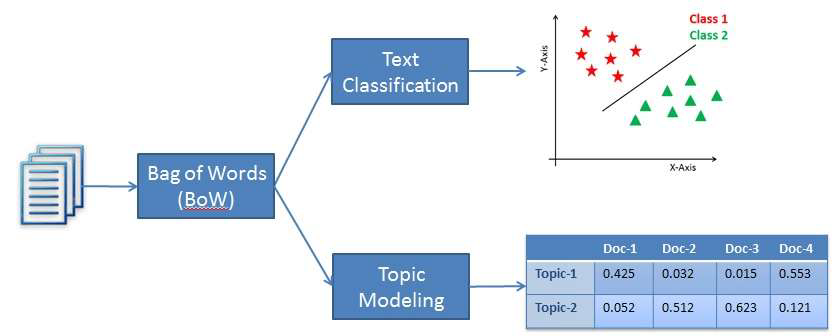

Entre os principais algoritmos dedicados à tarefa de modelagem de tópicos está o Latent Dirichlet Allocation (LDA), um algoritmo de aprendizado não supervisionado que tenta descrever um conjunto de textos como uma coleção de categorias (tópicos, grupos ou clusters) distintas. Os tópicos são aprendidos como uma distribuição de probabilidade sobre as palavras que ocorrem no corpus. Assim, o corpus pode ser descrito como uma combinação dos tópicos encontrados. Outros algoritmos importantes são: Gibbs Sampling Dirichlet Multinomial Mixture (GSDMM), Pseudo-document based Topic Model (PTM) e o BERTopic.

No nosso caso particular, o corpus é formado por um conjunto de mensagens compartilhadas no Telegram. Utilizando os dados referente a postagens no Telegram, descubra os tópicos presentes nessas mensagens.

A avaliação experimental deverá considerar:

a. O algoritmo de modelagem de tópicos: LDA, GSDMM, PTM e BERTopic.

In [1]:
import duckdb

conn = duckdb.connect()

telegram_data = conn.read_csv("../data/fakeTelegram.BR_2022.csv")

query = """
    SELECT * FROM telegram_data
"""

df = conn.execute(query).fetchdf()

df.head()

,date_message,id_member_anonymous,id_group_anonymous,media,media_type,media_url,has_media,has_media_url,trava_zap,text_content_anonymous,dataset_info_id,date_system,score_sentiment,score_misinformation,id_message,message_type,messenger,media_name,media_md5
0,2022-10-05 06:25:04,1078cc958f0febe28f4d03207660715f,12283e08a2eb5789201e105b34489ee7,None,None,None,False,False,False,Então é Fato Renato o áudio que eu ouvi no wha...,5,2022-10-05 06:25:28.863641,0.0000,NaN,16385,Texto,telegram,None,None
1,2022-10-05 06:25:08,None,12283e08a2eb5789201e105b34489ee7,None,None,None,False,False,False,"Saiu no YouTube do presidente a 8 horas atrás,...",5,2022-10-05 06:25:28.926311,0.0644,NaN,16386,Texto,telegram,None,None
2,2022-10-05 06:26:28,92a2d8fd7144074f659d1d29dc3751da,9f2d7394334eb224c061c9740b5748fc,None,None,None,False,False,False,"É isso, nossa parte já foi quase toda feita. N...",5,2022-10-05 06:26:29.361949,-0.3551,0.157242,16366,Texto,telegram,None,None
3,2022-10-05 06:27:28,d60aa38f62b4977426b70944af4aff72,c8f2de56550ed0bf85249608b7ead93d,94dca4cda503100ebfda7ce2bcc060eb.jpg,image/jpg,None,True,False,False,GENTE ACHEI ELES EM UMA SEITA MAÇONÁRICA,5,2022-10-05 06:27:29.935624,0.0000,NaN,19281,Imagem,telegram,None,94dca4cda503100ebfda7ce2bcc060eb
4,2022-10-05 06:27:44,cd6979b0b5265f08468fa1689b6300ce,e56ec342fc599ebb4ed89655eb6f03aa,5ad5c8bbe9da93a37fecf3e5aa5b0637.jpg,image/jpg,None,True,False,False,None,5,2022-10-05 06:28:29.316325,NaN,NaN,507185,Imagem,telegram,None,5ad5c8bbe9da93a37fecf3e5aa5b0637


In [2]:
df.shape

(557586, 19)

In [3]:
df = conn.execute(f"""
    SELECT * 
    FROM telegram_data
    WHERE trava_zap IS NOT TRUE
""").fetch_df()

In [4]:
df.shape

(557570, 19)

In [5]:
df_ = conn.execute("SELECT DISTINCT * FROM df").fetch_df()

In [6]:
query = """
SELECT *
FROM df_
WHERE array_length(string_split(text_content_anonymous, ' ')) >= 5
"""

df = conn.execute(query).fetch_df()

df.shape

(336944, 19)

In [7]:
import re
import unicodedata

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Converte para minúsculas
    text = text.lower()
    
    # 2. Remover URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 3. Remover caracteres árabes
    text = re.sub(r'[\u0600-\u06FF]+', '', text)
    
    # 4. Remover acentos (Normalização)
    text = unicodedata.normalize('NFKD', text)\
           .encode('ascii', 'ignore')\
           .decode('utf-8')
    
    # 5. Remover pontuação e caracteres especiais
    text = re.sub(r'[^\w\s]', '', text)
    
    # 6. Remover emojis 
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # símbolos & pictogramas
        u"\U0001F680-\U0001F6FF"  # transporte & símbolos
        u"\U0001F1E0-\U0001F1FF"  # bandeiras (iOS)
                           "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    
    # 7. Remover espaços extras (no início, fim e múltiplos espaços no meio)
    text = ' '.join(text.split())
    
    return text

df['cleaned_text'] = df['text_content_anonymous'].apply(clean_text)

In [8]:
import nltk

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

nltk.data.find('tokenizers/punkt')
nltk.data.find('corpora/stopwords')
    

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Pedro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Pedro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pedro\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


FileSystemPathPointer('C:\\Users\\Pedro\\AppData\\Roaming\\nltk_data\\corpora\\stopwords')

In [9]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('portuguese'))

def remove_stopwords(text):
    if not isinstance(text, str):
        return ""
    
    words = word_tokenize(text, language='portuguese') 
    
    filtered_words = [word for word in words if word.lower() not in stop_words]
    
    return ' '.join(filtered_words)

df['text_without_stopwords'] = df['cleaned_text'].apply(remove_stopwords)

print("Função aplicada com sucesso!")
print(df[['cleaned_text', 'text_without_stopwords']].head())

Função aplicada com sucesso!
                                        cleaned_text  \
0  o informante ele ja havia feito um bo denuncia...   
1               amigos voluntarios precisamos de vcs   
2  muito obrigado pelo seu feedback parabens cont...   
3  a servidora que teria recebido um email com in...   
4  estarrecedor pt pode ter armado tudo para inse...   

                              text_without_stopwords  
0  informante ja havia feito bo denunciando coisa...  
1                  amigos voluntarios precisamos vcs  
2  obrigado feedback parabens continue fazendo ne...  
3  servidora recebido email informacoes respeito ...  
4  estarrecedor pt pode ter armado tudo insercoes...  


In [10]:
from sklearn.feature_extraction.text import CountVectorizer


corpus = df['text_without_stopwords'].dropna()

# min_df=2: a palavra precisa aparecer em pelo menos 2 mensagens.
# max_df=0.95: a palavra não pode aparecer em mais de 95% das mensagens.
vectorizer = CountVectorizer(min_df=2, max_df=0.95)

# aprender o vocabulárioe criar a matriz dos dados
# o resultado é a nossa Matriz de Documentos-Termos (DTM)
dtm = vectorizer.fit_transform(corpus)

print("Formato da Matriz de Documentos-Termos (DTM):", dtm.shape)
# o primeiro número é a quantidade de mensagens, o segundo é o tamanho do vocabulário.

feature_names = vectorizer.get_feature_names_out()
print("Exemplo de palavras no vocabulário:", feature_names[500:510])

Formato da Matriz de Documentos-Termos (DTM): (336944, 92211)
Exemplo de palavras no vocabulário: ['080922' '081' '0810' '081010' '08102019' '08102022' '081022' '0811'
 '08111929' '08112022']


In [11]:
from sklearn.decomposition import LatentDirichletAllocation

# definir o número de tópicos
n_topicos = 5

lda = LatentDirichletAllocation(n_components=n_topicos, random_state=42, n_jobs=-1)

lda.fit(dtm)

# o resultado do LDA não é imediatamente legível. Precisamos de uma função
# para nos mostrar as palavras mais importantes de cada tópico.

def exibe_topicos(modelo, feature_names, n_top_words):
    print("\n--- Tópicos encontrados pelo LDA ---")
    for topic_idx, topic in enumerate(modelo.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        
        top_features = [feature_names[i] for i in top_features_ind]
        
        message = f"Tópico #{topic_idx}: "
        message += ", ".join(top_features)
        print(message)

n_palavras_top = 10
feature_names = vectorizer.get_feature_names_out()
exibe_topicos(lda, feature_names, n_palavras_top)


--- Tópicos encontrados pelo LDA ---
Tópico #0: brazil, tse, superior, of, the, in, this, following, was, decision
Tópico #1: nao, lula, bolsonaro, brasil, sao, presidente, contra, pt, turno, sobre
Tópico #2: nao, bolsonaro, pra, ja, vai, povo, todos, deus, user, so
Tópico #3: 13, to, the, 22, and, you, this, is, of, user
Tópico #4: user, voce, grupo, 55, intervencao, militar, link, phone, plataforma, vpn


In [12]:
!!pip install git+https://github.com/rwalk/gsdmm.git

['Collecting git+https://github.com/rwalk/gsdmm.git',
 '  Cloning https://github.com/rwalk/gsdmm.git to c:\\users\\pedro\\appdata\\local\\temp\\pip-req-build-jioym7md',
 "  Running command git clone --filter=blob:none --quiet https://github.com/rwalk/gsdmm.git 'C:\\Users\\Pedro\\AppData\\Local\\Temp\\pip-req-build-jioym7md'",
 '  Resolved https://github.com/rwalk/gsdmm.git to commit 4ad1b6b6976743681ee4976b4573463d359214ee',
 '  Preparing metadata (setup.py): started',
 "  Preparing metadata (setup.py): finished with status 'done'",
 'Requirement already satisfied: numpy in c:\\users\\pedro\\miniforge3\\envs\\cd\\lib\\site-packages (from gsdmm==0.1) (2.2.6)']

In [13]:
corpus = df['text_without_stopwords'].dropna()

# tokenizar cada documento (mensagem)
# o resultado será uma lista, onde cada item é outra lista contendo as palavras da mensagem.
docs_tokenized = [text.split() for text in corpus]

# criar o vocabulário (um conjunto de todas as palavras únicas no corpus)
vocab = set(word for doc in docs_tokenized for word in doc)

print(f"Total de documentos: {len(docs_tokenized)}")
print(f"Tamanho do vocabulário: {len(vocab)}")
print("\nExemplo de documento tokenizado:")
print(docs_tokenized[0])

Total de documentos: 336944
Tamanho do vocabulário: 179967

Exemplo de documento tokenizado:
['informante', 'ja', 'havia', 'feito', 'bo', 'denunciando', 'coisa', 'errada', 'ignorou', 'deu', 'ordens', 'ja', 'apreenderam', 'celular', 'quebraram', 'sigilo', 'midia', 'vergonha', 'caladinha', 'caiu', 'casa', 'tse', 'denunciou', 'falhas', 'desde', '2018', 'tse', 'ignorou', 'tse', 'sabia', 'tudo', 'acontecendo', 'ta', 'tudo', 'casa', 'lula']


In [14]:
from gsdmm import MovieGroupProcess

# K: O número de tópicos que queremos encontrar (similar ao n_components do LDA).
# alpha, beta: Hiperparâmetros do modelo. Valores padrão (0.1).
# n_iters: Número de vezes que o algoritmo passará pelos dados.
gsdmm = MovieGroupProcess(K=5, alpha=0.1, beta=0.1, n_iters=20)


clusters = gsdmm.fit(docs_tokenized, len(vocab))



In stage 0: transferred 262936 clusters with 5 clusters populated
In stage 1: transferred 113842 clusters with 5 clusters populated
In stage 2: transferred 28608 clusters with 5 clusters populated
In stage 3: transferred 18033 clusters with 5 clusters populated
In stage 4: transferred 15966 clusters with 5 clusters populated
In stage 5: transferred 15333 clusters with 5 clusters populated
In stage 6: transferred 14933 clusters with 5 clusters populated
In stage 7: transferred 14525 clusters with 5 clusters populated
In stage 8: transferred 14086 clusters with 5 clusters populated
In stage 9: transferred 14237 clusters with 5 clusters populated
In stage 10: transferred 14218 clusters with 5 clusters populated
In stage 11: transferred 14030 clusters with 5 clusters populated
In stage 12: transferred 14033 clusters with 5 clusters populated
In stage 13: transferred 13942 clusters with 5 clusters populated
In stage 14: transferred 14097 clusters with 5 clusters populated
In stage 15: trans

In [15]:
def exibe_topicos_gsdmm(modelo, n_top_words):
    print("\n--- Tópicos encontrados pelo GSDMM ---")
    
    # o modelo armazena a distribuição de palavras como uma LISTA de dicionários
    topicos = modelo.cluster_word_distribution
    
    for cluster_idx, dist in enumerate(topicos):        
        # ordena as palavras pela sua frequência no cluster
        sorted_words = sorted(dist.items(), key=lambda item: item[1], reverse=True)
        
        # pega as 'n_top_words' palavras mais importantes
        top_features = [word for word, count in sorted_words[:n_top_words]]
        
        message = f"Tópico #{cluster_idx}: "
        message += ", ".join(top_features)
        print(message)

exibe_topicos_gsdmm(gsdmm, 10)


--- Tópicos encontrados pelo GSDMM ---
Tópico #0: nao, bolsonaro, pra, vai, ja, brasil, presidente, so, povo, lula
Tópico #1: user, voce, telegram, welcome, groups, professional, tool, managing, aqui, ganhar
Tópico #2: grupo, user, canal, bolsonaro, link, liberdade, bem, youtube, verdade, abaixo
Tópico #3: the, this, of, in, was, brazil, decision, court, following, community
Tópico #4: nao, 13, bolsonaro, lula, brasil, presidente, intervencao, sao, militar, todos


In [16]:
!pip install git+https://github.com/markoarnauto/biterm

  Cloning https://github.com/markoarnauto/biterm to c:\users\pedro\appdata\local\temp\pip-req-build-joo4tw1f
  Resolved https://github.com/markoarnauto/biterm to commit 4ee60d9131a321a8cac618bce6e9a17b4733864d
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/markoarnauto/biterm 'C:\Users\Pedro\AppData\Local\Temp\pip-req-build-joo4tw1f'


In [ ]:
from biterm.btm import oBTM
from itertools import combinations, chain
from tqdm import trange
import numpy as np

corpus = df['text_without_stopwords'].dropna()
docs_tokenized = [text.split() for text in corpus]

vocab = list(set(word for doc in docs_tokenized for word in doc))
word_to_id = {word: i for i, word in enumerate(vocab)}


def docs_to_biterms(docs, word_to_id_map):
    biterm_docs = []
    for doc in docs:
        doc_ids = [word_to_id_map[word] for word in doc if word in word_to_id_map]
        doc_biterms = list(combinations(doc_ids, 2))
        biterm_docs.append(doc_biterms)
    return biterm_docs

biterms = docs_to_biterms(docs_tokenized, word_to_id)


btm_model = oBTM(num_topics=5, V=word_to_id, alpha=10.0, beta=0.01)

btm_model.fit(biterms, iterations=25)

def exibe_topicos_btm_final(modelo, vocab_list, n_top_words):
    print("\n--- Tópicos encontrados pelo BTM---")
    for i in range(modelo.K):
        topic_probs = modelo.phi_wz[:, i]
        top_indices = np.argsort(topic_probs)[::-1][:n_top_words]
        top_words = [vocab_list[idx] for idx in top_indices]
        print(f"Tópico #{i}: {', '.join(top_words)}")

exibe_topicos_btm_final(btm_model, vocab, 10)